In [103]:
import keras
from keras.models import Sequential
from keras.layers import Dense,BatchNormalization
import pandas as pd
from sklearn.model_selection import train_test_split
from numpy.random import seed
import matplotlib.pyplot as plt


In [104]:
data= pd.read_csv("kdd_train_prep2_AE_25_KM.csv")

In [105]:
data.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_23,feature_24,attack,label_2,label_5,Class_2,Class_5,pred_2,pred_5,pred_lb
0,-0.048148,0.488681,0.131504,0.489313,0.212695,-0.202763,0.238999,0.200140,-0.410348,-0.188797,...,-0.405918,0.011307,normal,normal,Normal,1,1,1,2,Probe
1,-0.402155,0.445627,-0.199527,-0.222194,-0.497194,-0.003040,-0.344050,0.452415,0.270634,-0.384953,...,0.137411,-0.092514,normal,normal,Normal,1,1,1,3,U2R
2,-0.341143,0.227453,0.102329,0.140638,-0.157997,-0.031205,-0.374357,-0.142030,-0.189176,-0.343771,...,-0.038431,-0.438291,neptune,attack,DoS,0,0,0,0,DoS
3,-0.012742,0.481216,-0.263470,0.071221,0.295141,0.258493,0.002097,0.103495,0.349877,-0.380654,...,0.267029,-0.487912,normal,normal,Normal,1,1,1,4,Normal
4,-0.050274,0.480140,-0.240462,0.073677,0.263350,0.232209,-0.012105,0.106856,0.351176,-0.389411,...,0.377997,-0.304641,normal,normal,Normal,1,1,1,4,Normal


In [106]:
#data['cluster_Id']=data['cluster_Id'].apply(lambda x: 1 if x=='Normal' else 0)

In [107]:
y=data.pop('pred_2')
X=data

In [108]:
y.value_counts()

1    77917
0    48056
Name: pred_2, dtype: int64

In [109]:
X.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_22,feature_23,feature_24,attack,label_2,label_5,Class_2,Class_5,pred_5,pred_lb
0,-0.048148,0.488681,0.131504,0.489313,0.212695,-0.202763,0.238999,0.200140,-0.410348,-0.188797,...,0.093731,-0.405918,0.011307,normal,normal,Normal,1,1,2,Probe
1,-0.402155,0.445627,-0.199527,-0.222194,-0.497194,-0.003040,-0.344050,0.452415,0.270634,-0.384953,...,0.275891,0.137411,-0.092514,normal,normal,Normal,1,1,3,U2R
2,-0.341143,0.227453,0.102329,0.140638,-0.157997,-0.031205,-0.374357,-0.142030,-0.189176,-0.343771,...,-0.031489,-0.038431,-0.438291,neptune,attack,DoS,0,0,0,DoS
3,-0.012742,0.481216,-0.263470,0.071221,0.295141,0.258493,0.002097,0.103495,0.349877,-0.380654,...,-0.026611,0.267029,-0.487912,normal,normal,Normal,1,1,4,Normal
4,-0.050274,0.480140,-0.240462,0.073677,0.263350,0.232209,-0.012105,0.106856,0.351176,-0.389411,...,-0.006169,0.377997,-0.304641,normal,normal,Normal,1,1,4,Normal


In [110]:
X.shape

(125973, 32)

In [111]:
X_train, X_val,y_train, y_val = train_test_split(X,y, train_size = 0.7, test_size = 0.3, random_state = seed(100))

In [112]:
label_list=['attack', 'label_2','label_5','Class_2','Class_5','pred_5','pred_lb']

X_train_label=X_train[label_list]
X_train.drop(label_list, axis = 1, inplace = True)
X_val_label=X_val[label_list]
X_val.drop(label_list, axis = 1, inplace = True)

X_label=X[label_list]

X_label=X[label_list]
X.drop(label_list, axis = 1, inplace = True)


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/pandas/core/frame.py:3697: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  errors=errors)


In [113]:
# define the keras model
model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='elu'))
#model.add(BatchNormalization())
model.add(Dense(8, activation='elu'))
#model.add(BatchNormalization())
model.add(Dense(4, activation='elu'))
model.add(Dense(1, activation='tanh'))
#model.add(Dense(1, activation='softmax'))


In [114]:
# compile the keras model
opt = keras.optimizers.Adam(lr=0.001)
model.compile(loss='mse', optimizer=opt, metrics=['accuracy'])

In [115]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_9 (Dense)              (None, 10)                260       
_________________________________________________________________
dense_10 (Dense)             (None, 8)                 88        
_________________________________________________________________
dense_11 (Dense)             (None, 4)                 36        
_________________________________________________________________
dense_12 (Dense)             (None, 1)                 5         
Total params: 389
Trainable params: 389
Non-trainable params: 0
_________________________________________________________________


In [116]:
import time
start_time = time.time()
history=model.fit(X_train, y_train, epochs = 20, batch_size = 50, shuffle = False, validation_data = (X_val, y_val))

print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))


Train on 88181 samples, validate on 37792 samples
Epoch 1/20
88181/88181 [==============================] - 8s 91us/step - loss: 0.0201 - acc: 0.9817 - val_loss: 0.0032 - val_acc: 0.9981
Epoch 2/20
88181/88181 [==============================] - 8s 91us/step - loss: 0.0025 - acc: 0.9979 - val_loss: 0.0017 - val_acc: 0.9990
Epoch 3/20
88181/88181 [==============================] - 8s 89us/step - loss: 0.0015 - acc: 0.9986 - val_loss: 0.0011 - val_acc: 0.9991
Epoch 4/20
88181/88181 [==============================] - 8s 86us/step - loss: 0.0010 - acc: 0.9990 - val_loss: 7.5682e-04 - val_acc: 0.9992
Epoch 5/20
88181/88181 [==============================] - 8s 88us/step - loss: 7.8422e-04 - acc: 0.9991 - val_loss: 5.8170e-04 - val_acc: 0.9995
Epoch 6/20
88181/88181 [==============================] - 8s 88us/step - loss: 6.7145e-04 - acc: 0.9992 - val_loss: 5.0266e-04 - val_acc: 0.9996
Epoch 7/20
88181/88181 [==============================] - 8s 86us/step - loss: 6.0705e-04 - acc: 0.9993 - va

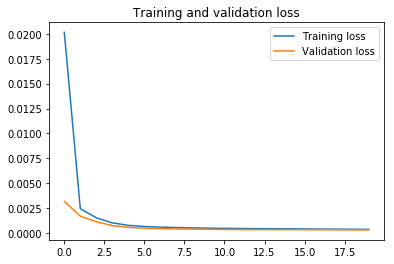

In [117]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(20)
plt.figure()
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

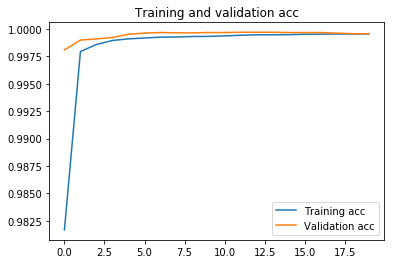

In [118]:
loss = history.history['acc']
val_loss = history.history['val_acc']
epochs = range(20)
plt.figure()
plt.plot(epochs, loss, label='Training acc')
plt.plot(epochs, val_loss, label='Validation acc')
plt.title('Training and validation acc')
plt.legend()
plt.show()

# fit the keras model on the dataset
model.fit(X_train, y_train, epochs=15, batch_size=50)


In [119]:
def metrics_df_2(y_train, y_pred):
    
    
    print("\n*********************************SKLEARN METRICS***********\n")
    import sklearn.metrics
    print(sklearn.metrics.classification_report(y_train,  y_pred),"\n\n")
    print("Confusion Matrix :\n",sklearn.metrics.confusion_matrix(y_train, y_pred))

    print("Accuracy : \t",sklearn.metrics.accuracy_score(y_train, y_pred,normalize=True))
    
    print('MCC: \t', sklearn.metrics.matthews_corrcoef(y_train, y_pred))
    print('cOHEN kAPPA sCORE: \t',sklearn.metrics.cohen_kappa_score(y_train, y_pred))
    print('Cross Entropy: \t',sklearn.metrics.log_loss(y_train, y_pred))
    

    print("F1_score : \t",sklearn.metrics.f1_score(y_train, y_pred))

    print("Precision : \t",sklearn.metrics.precision_score(y_train, y_pred))

    print("Recall : \t",sklearn.metrics.recall_score(y_train, y_pred))

    print("ROC_AUC : \t",sklearn.metrics.roc_auc_score(y_train, y_pred))  
    
    
    
    print("\n*************************CONFUSION MATRIX***********\n")
    from sklearn.metrics import confusion_matrix
    confusion=sklearn.metrics.confusion_matrix(y_train, y_pred)
    TP = confusion[1,1] # true positive 
    TN = confusion[0,0] # true negatives
    FP = confusion[0,1] # false positives
    FN = confusion[1,0] # false negatives
    
    # Let's see the sensitivity  and precison of our logistic regression model
    
    # Let's see the sensitivity of our logistic regression model
    print('Accuracy: {}'.format((TP + TN)/ float(TP + TN + FP + FN)))
    bcr=0.5* (TP / (TP + FN) + TN / (TN + FP))
    print('Balanced Accuracy: {}'.format(bcr))
    print('Recall/TPR/Sensitivity/hit-rate:\t {}'.format(TP / float(TP+FN)))
    print('Precision :\t {}'.format(TP / float(TP+FP)))
    p=TP / float(TP+FP)
    r=TP / float(TP+FN)
    print('F1-SCORE: {}'.format(2*p*r /float (p+r)))
    # Let us calculate specificity
    print('Specificity :\t {}'.format(TN / float(TN+FP)))
    # Let us calculate specificity
     # Calculate false postive rate - predicting churn when customer does not have churned
    #print('Accuracy :\t {}'.format((TP + TN)/ float(TP + TN + FP + FN)))

    print('Detection Rate  :\t {}'.format(TP/ float(TP + TN + FP + FN)))

    print('False Positive Rate :\t {}'.format(FP/ float(TN+FP)))
    #False Negative
    print('False Negative Rate  :\t {}'.format(FN/ float(TP+FN)))
    ## Misclassification Rtae : FP + FN / TP + TN + FP + FN
    print('Missclassification Rate :\t {}'.format((FP + FN)/ float(TP + TN + FP + FN)))
    # positive predictive value 
    print('Positive predictive value :\t {}'.format(TP / float(TP+FP)))
    # Negative predictive value
    print('Negative Predictive value :\t {}'.format(TN / float(TN+ FN)))
    
    print(confusion)
    
    
    plot_confusion_matrix(confusion,['attack','normal'])


In [120]:
import numpy as np


def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=False):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 1.25
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()


accuracy = model.evaluate(X, y)
print('Accuracy: %.2f' % (accuracy*100))

In [121]:
pred = model.predict_classes(X)

In [122]:
X_label['pred']=pred

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [123]:
X_label['pred'].value_counts()

1    77911
0    48062
Name: pred, dtype: int64

In [124]:
print(pd.crosstab(X_label['label_5'], X_label['pred']),"\n")


pred         0      1
label_5              
DoS      41136   4791
Normal    1155  66188
Probe     5709   5947
R2L         61    934
U2R          1     51 



In [125]:
print(pd.crosstab(X_label['label_2'], X_label['pred']),"\n")


pred         0      1
label_2              
attack   46907  11723
normal    1155  66188 



In [126]:
y_train=X_label['Class_2']

In [127]:
y_train.value_counts()

1    67343
0    58630
Name: Class_2, dtype: int64

In [128]:
X_label['pred'].value_counts()

1    77911
0    48062
Name: pred, dtype: int64

In [129]:
y_pred=X_label['pred']

import sklearn
print(sklearn.metrics.classification_report(y_train, y_pred))


*********************************SKLEARN METRICS***********

             precision    recall  f1-score   support

          0       0.98      0.80      0.88     58630
          1       0.85      0.98      0.91     67343

avg / total       0.91      0.90      0.90    125973
 


Confusion Matrix :
 [[46907 11723]
 [ 1155 66188]]
Accuracy : 	 0.897771744738952
MCC: 	 0.80391892541418
cOHEN kAPPA sCORE: 	 0.7921368987622965
Cross Entropy: 	 3.5309132599393043
F1_score : 	 0.9113415121098215
Precision : 	 0.8495334420043383
Recall : 	 0.9828489969261839
ROC_AUC : 	 0.8914500826350176

*************************CONFUSION MATRIX***********

Accuracy: 0.897771744738952
Balanced Accuracy: 0.8914500826350176
Recall/TPR/Sensitivity/hit-rate:	 0.9828489969261839
Precision :	 0.8495334420043383
F1-SCORE: 0.9113415121098215
Specificity :	 0.8000511683438513
Detection Rate  :	 0.5254141760535987
False Positive Rate :	 0.19994883165614874
False Negative Rate  :	 0.017151003073816135
Missclassificatio

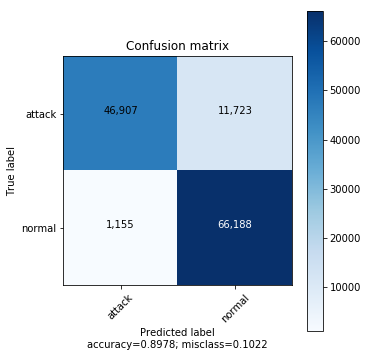

In [130]:
metrics_df_2(y_train, y_pred)

### test data

In [131]:
test_data= pd.read_csv("kdd_test_prep2_AE_25.csv")

In [132]:
test_data.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,attack,label_2,label_5
0,-0.163598,0.277565,-0.334397,0.171446,0.200564,0.174593,0.008552,-0.113978,-0.008205,-0.137735,...,0.483049,0.386924,0.381773,-0.008411,-0.210705,0.093459,-0.423185,neptune,attack,DoS
1,-0.152054,0.283621,-0.346007,0.178448,0.191547,0.211349,-0.006470,-0.099515,0.034336,-0.134315,...,0.480194,0.396483,0.374323,-0.020643,-0.250668,0.107579,-0.438055,neptune,attack,DoS
2,0.121908,0.140974,-0.124887,0.070539,0.342300,-0.233420,-0.262475,0.138421,0.524137,-0.459112,...,0.311639,0.058980,0.592991,0.433032,0.443042,-0.443852,0.389567,normal,normal,Normal
3,0.078415,0.232749,0.560901,-0.719913,0.024467,0.488218,-0.732139,0.494942,-0.562065,0.102110,...,0.465536,-0.485968,0.872847,0.647007,0.627276,-0.307057,-0.211049,saint,attack,Probe
4,0.470687,0.395612,0.198775,0.353252,-0.123358,0.442603,-0.116367,0.014621,-0.069358,-0.176192,...,-0.632003,-0.015951,0.308758,-0.300906,-0.006010,-0.378421,0.529611,mscan,attack,Probe


In [133]:
test_data['Class_2']=test_data['label_2'].apply(lambda x: 1 if x=='normal' else 0)
test_data['Class_2'].value_counts()

0    12833
1     9711
Name: Class_2, dtype: int64

In [134]:
label_list=['attack', 'label_2','label_5','Class_2']
kdd_test_label=test_data[label_list]
test_data.drop(label_list, axis = 1, inplace = True)

In [135]:
y_test=kdd_test_label['Class_2']

In [136]:
test_data.shape

(22544, 25)

In [137]:
import time
start_time=time.time()
pred_t = model.predict_classes(test_data)
print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))




Run Time -> --- 0.5617921352386475 seconds ---


In [148]:
kdd_test_label['pred']=pred_t

/mnt/disks/user/anaconda3/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [149]:
kdd_test_label['pred'].value_counts()

0    14753
1     7791
Name: pred, dtype: int64

In [150]:
kdd_test_label['label_5'].value_counts()

Normal     9711
DoS        7167
R2L        2885
Probe      2421
unknown     293
U2R          67
Name: label_5, dtype: int64

In [151]:
print(pd.crosstab(kdd_test_label['label_5'], kdd_test_label['pred']),"\n")


pred        0     1
label_5            
DoS      3015  4152
Normal   8480  1231
Probe     839  1582
R2L      2105   780
U2R        21    46
unknown   293     0 



In [152]:
print(pd.crosstab(kdd_test_label['Class_2'], kdd_test_label['pred']),"\n")


pred        0     1
Class_2            
0        6273  6560
1        8480  1231 



In [153]:
test_pred=kdd_test_label['pred']

In [154]:
test_pred=kdd_test_label['pred'].apply(lambda x: 0 if x==1 else 1)
test_pred.value_counts()

1    14753
0     7791
Name: pred, dtype: int64

In [155]:
print(pd.crosstab(kdd_test_label['label_5'], test_pred),"\n")


pred        0     1
label_5            
DoS      4152  3015
Normal   1231  8480
Probe    1582   839
R2L       780  2105
U2R        46    21
unknown     0   293 



In [156]:
print(pd.crosstab(kdd_test_label['label_2'], test_pred),"\n")


pred        0     1
label_2            
attack   6560  6273
normal   1231  8480 



In [157]:
y_test=kdd_test_label['Class_2']



*********************************SKLEARN METRICS***********

             precision    recall  f1-score   support

          0       0.84      0.51      0.64     12833
          1       0.57      0.87      0.69      9711

avg / total       0.73      0.67      0.66     22544
 


Confusion Matrix :
 [[6560 6273]
 [1231 8480]]
Accuracy : 	 0.6671398154719659
MCC: 	 0.4002798642607304
cOHEN kAPPA sCORE: 	 0.36158258820874434
Cross Entropy: 	 11.496805976849245
F1_score : 	 0.6932635709614128
Precision : 	 0.5747983460990985
Recall : 	 0.8732365358871383
ROC_AUC : 	 0.6922093222566682

*************************CONFUSION MATRIX***********

Accuracy: 0.6671398154719659
Balanced Accuracy: 0.6922093222566682
Recall/TPR/Sensitivity/hit-rate:	 0.8732365358871383
Precision :	 0.5747983460990985
F1-SCORE: 0.6932635709614128
Specificity :	 0.5111821086261981
Detection Rate  :	 0.376153300212917
False Positive Rate :	 0.48881789137380194
False Negative Rate  :	 0.1267634641128617
Missclassification 

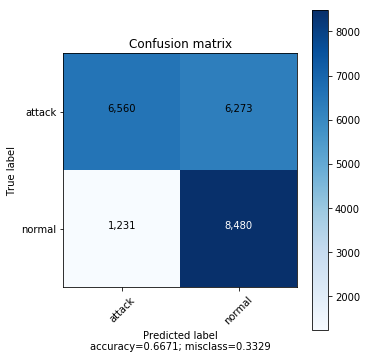

In [158]:
metrics_df_2(y_test,test_pred)